---
title: "2D Inversion of Impedance Data"
authors:
  - id: devincowan
---

```{admonition} Intermediate notebook
:class: caution
This tutorial focusses on intermediate level functionality within SimPEG. Basic functionality within SimPEG is not discussed in detail, as we assume the user is already familiar. 
```

```{admonition} Light-weight notebook
:class: hint
This tutorial requires minimal computational resources and can be executed quickly in the background while other computer processes are running.
```

**Keywords:** DC resistivity, 2.5D inversion, sparse norm, tree mesh.

</br>

**Summary:** Here we invert DC resistivity data on a tree mesh to recover the subsurface distribution of electric properties. To demonstrate a range of functionality within SimPEG, we apply two approaches:

1. Weighted least-squares inversion, where we invert normalized voltage data to recover a log-conductivity model
2. Iteratively re-weighted least-squares (IRLS) inversion, where we invert apparent resistivity data to recover a log-resistivity model

The *weighted least-squares* approach is a great introduction to geophysical inversion with SimPEG. One drawback however, is that it recovers smooth structures which may not be representative of the true model. The *iteratively re-weighted least-squares* approach is able to recover sparse and/or blocky structures. Because this tutorial focusses primarily on 
inversion-related functionality, we urge the reader to become familiar with functionality explained in the [2.5D Forward Simulation](fwd_dcr_2d.ipynb) tutorial before working through this one.

</br>

**Learning Objectives:**

- Introduce geophysical inversion with SimPEG.
- Assigning appropriate uncertainties to normalized voltage and apparent resistivity data.
- Designing a suitable mesh for 2.5D DC resistivity inversion.
- Choosing suitable parameters for the inversion.
- Specifying directives that are applied throughout the inversion.
- Apply the sensitivity weighting commonly used when inverting magnetic data.
- Inversion with weighted least-squares and sparse-norm regularizations.
- Analyzing inversion outputs.

## Import Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise.
All of the functionality specific to DC resistivity is imported from [simpeg.electromagnetics.static.resistivity](xref:simpeg#simpeg.electromagnetics.static.resistivity).
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils). Classes required to define the data misfit, regularization, optimization, etc... are imported from elsewhere within SimPEG. We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils). To generate the mesh used for the inversion, we use the [discretize](https://discretize.simpeg.xyz/en/main) package.

In [1]:
# SimPEG functionality
import simpeg.electromagnetics.natural_source as nsem
from simpeg.utils import (
    model_builder, get_default_solver, shift_to_discrete_topography
)
from simpeg.utils import download, model_builder
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)

# discretize functionality
from discretize import TreeMesh, TensorMesh
from discretize.utils import active_from_xyz

# Basic Python functionality
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import tarfile

mpl.rcParams.update({"font.size": 14})  # default font size
cmap = mpl.cm.RdYlBu_r  # default colormap

## Load Tutorial Data and Plot

For most geophysical inversion projects, a reasonable inversion result can be obtained so long as the practitioner has observed data, the survey geometry and topography. For this tutorial, the observed data and topography files are provided. Here, we download and import the observed data and topography into the SimPEG framework.

In [2]:
# URL to download from repository assets
# data_source = "https://github.com/simpeg/user-tutorials/raw/main/assets/05-dcr/inv_dcr_2d_files.tar.gz"

# # download the data
# downloaded_data = download(data_source, overwrite=True)

# # unzip the tarfile
# tar = tarfile.open(downloaded_data, "r")
# tar.extractall()
# tar.close()

# # path to the directory containing our data
# dir_path = downloaded_data.split(".")[0] + os.path.sep
dir_path = './fwd_nsem_2d_outputs/'

# files to work with
topo_filename = dir_path + "topo_2d.txt"
freq_filename = dir_path + "frequencies_mt.npy"
loc_filename = dir_path + "locations_mt.npy"
dobs_Zxy_filename = dir_path + "dobs_Zxy.npy"
dobs_Zyx_filename = dir_path + "dobs_Zyx.npy"

### Load the Topography

True surface topography is defined as an (N, 3) [numpy.ndarray](xref:numpy#numpy.ndarray).
For the 2.5D problem geometry however, topography is an (N, 2) [numpy.ndarray](xref:numpy#numpy.ndarray), where the first coordinate represent along-line position and the second coordinate represents the vertical position. In this tutorial, we assume the topography and electrode locations are defined according to the 2.5D geometry.

In [3]:
# Load 2D topography
topo_2d = np.loadtxt(str(topo_filename))

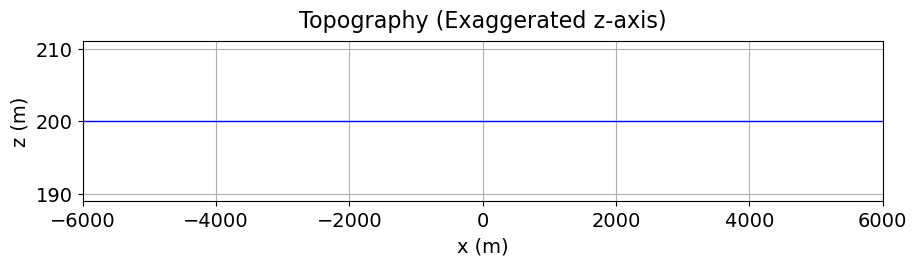

In [4]:
# Plot 2D topography
fig = plt.figure(figsize=(10, 2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(topo_2d[:, 0], topo_2d[:, -1], color="b", linewidth=1)
ax.set_xlim([topo_2d[:, 0].min(), topo_2d[:, 0].max()])
ax.set_xlabel("x (m)", labelpad=5)
ax.set_ylabel("z (m)", labelpad=5)
ax.grid(True)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=10)
plt.show(fig)

### Load and Plot Impedance Data

In [5]:
frequencies = np.load(freq_filename)
locations = np.load(loc_filename)
dobs_Zxy = np.load(dobs_Zxy_filename)
dobs_Zyx = np.load(dobs_Zyx_filename)

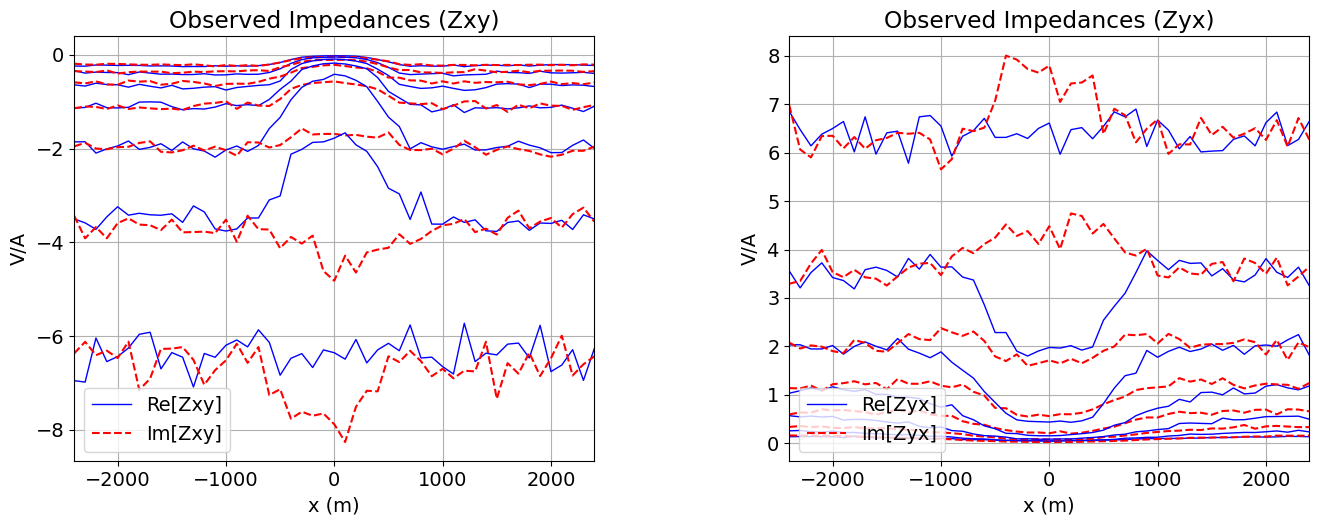

In [6]:
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.85])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.85])

for kk in range(len(frequencies)):
    ax1.plot(locations[:, 0], dobs_Zxy[kk, 0, :], 'b', lw=1)
    ax1.plot(locations[:, 0], dobs_Zxy[kk, 1, :], 'r--', lw=1.5)
    ax2.plot(locations[:, 0], dobs_Zyx[kk, 0, :], 'b', lw=1)
    ax2.plot(locations[:, 0], dobs_Zyx[kk, 1, :], 'r--', lw=1.5)

ax1.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
ax1.set_xlabel("x (m)", labelpad=5)
ax1.grid(which='both')
ax1.set_ylabel("V/A", labelpad=5)
ax1.set_title("Observed Impedances (Zxy)")
ax1.legend(['Re[Zxy]', 'Im[Zxy]'], loc='lower left')

ax2.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
ax2.set_xlabel("x (m)", labelpad=5)
ax2.grid(which='both')
ax2.set_ylabel("V/A", labelpad=5)
ax2.set_title("Observed Impedances (Zyx)")
ax2.legend(['Re[Zyx]', 'Im[Zyx]'], loc='lower left')

plt.show(fig)

## Assign Uncertainties

Inversion with SimPEG requires that we define the uncertainties on our data; that is, an estimate of the standard deviation of the noise on our data assuming it is uncorrelated Gaussian with zero mean. An online resource explaining uncertainties and their role in the inversion can be found [here](https://giftoolscookbook.readthedocs.io/en/latest/content/fundamentals/Uncertainties.html).

**For normalized voltage data,** we generally apply a percent uncertainty and a very small floor uncertainty to all data. Differences in electrode spacing and subsurface conductivity result in measured voltages that span many orders of magnitude. A percent uncertainty ensures all data are fit equally. Depending on the quality of the data, we may choose a percent uncertainty between 2% - 10%. The floor uncertainty ensures stability when there are zero-crossings or erroneously small voltages. Here, we apply uncertainties of 1e-7 V/A + 5 %.

**For apparent resistivity data,** we also apply a percent uncertainty and a very small floor uncertainty to all data. A percent uncertainty will fit conductive and resistive structures equally; unlike a floor uncertainty which will prioritize fitting more resistive structures. Depending on the quality of the data, we may choose a percent uncertainty between 2% - 10%. The floor uncertainty ensures stability when there are zero-crossings or erroneously small voltages.

In [7]:
unc_xy = 0.05 * np.abs(dobs_Zxy)
unc_yx = 0.05 * np.abs(dobs_Zyx)

## Design a (Tree) Mesh

The same rules for defining appropriate meshes for forward simulation of DC resistivity apply to inversion. Please visit the [2.5D Forward Simulation](fwd_dcr_2d.ipynb) tutorial to see the best practices for mesh design.

**Tutorial mesh:** Here, a minimum cell width of 4 m (or 1/10 the minimum electrode spacing) is used within our survey region. The largest electrode spacing was 400 m, so a the padding was extended at least 1200 m from the survey region. Using the [refine_surface](xref:discretize#discretize.TreeMesh.refine_surface) method, we refine the tree mesh where there is significant topography. And using the [refine_points](xref:discretize#discretize.TreeMesh.refine_points) methods, we refine based on electrodes locations. Visit the [tree mesh](xref:discretize#discretize.TreeMesh) API to see additional refinement methods.

In [8]:
# Minimum skin depth
500. / np.sqrt(5e-1 * frequencies.max())

7.071067811865475

In [9]:
# Maximum skin depth
500. / np.sqrt(1e-3 * frequencies.min())

5000.0

In [10]:
dh = 10  # base cell width
dom_width_x = 40000.0  # domain width x
dom_width_z = 40000.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh with top at z = 0 m.
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hz], x0="CC", diagonal_balance=True)

# Shift vertically by maximum topography
mesh.origin = mesh.origin + np.r_[0.0, topo_2d[:, -1].max()]

# Coarse mesh refinement based on topography
mesh.refine_surface(
    topo_2d,
    padding_cells_by_level=[0, 0, 4, 4, 8, 8],
    finalize=False,
)

# Mesh refinement for core region
inds = (topo_2d[:, 0] > -2800.) & (topo_2d[:, 0] < 2800.)
mesh.refine_surface(
    topo_2d[inds, :],
    # padding_cells_by_level=[10, 10, 10, 6, 6, 6, 4],
    padding_cells_by_level=[8, 8, 6, 6, 6, 4],
    finalize=False,
)

# Refine around receiver locations
mesh.refine_points(
    # locations, padding_cells_by_level=[6, 6, 6, 4, 4], finalize=False
    locations, padding_cells_by_level=[4, 4, 4, 4], finalize=False
)

mesh.finalize()

In [11]:
mesh.n_cells

21082

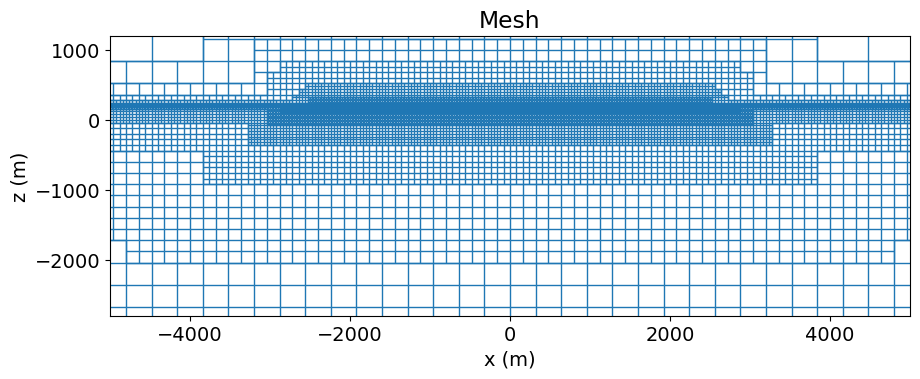

In [12]:
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.8, 0.7])
mesh.plot_grid(ax=ax1, linewidth=1)
ax1.grid(False)
ax1.set_xlim(-5000, 5000)
ax1.set_ylim(np.max(topo_2d[:, -1]) - 3000, np.max(topo_2d[:, -1])+1000)
ax1.set_title("Mesh")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

plt.show()

## Define the Active Cells

Simulated geophysical data are dependent on the subsurface distribution of physical property values. As a result, the cells lying below the surface topography are commonly referred to as 'active cells'. And air cells, whose physical property values are fixed, are commonly referred to as 'inactive cells'. Here, the discretize [active_from_xyz](xref:discretize#discretize.utils.active_from_xyz) utility function is used to find the indices of the active cells using the mesh and surface topography. The output quantity is a ``bool`` array.

In [13]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_2d)

# number of active cells
n_active = np.sum(active_cells)

### Mapping from the Model to the Mesh

In SimPEG, the term 'model' is not synonymous with the physical property values defined on the mesh. For whatever model we choose, we must define a mapping from the set of model parameters (a [1D numpy.ndarray](xref:numpy#numpy.ndarray)) to the physical property values of all cells in the mesh. Mappings are created using the [simpeg.maps](xref:simpeg#simpeg.maps.IdentityMap) module.

For DC resistivity, the model parameters define the subsurface electrical conductivity, and the electrical conductivities of the cells in the air are given a fixed value. Here, the model defines the log-conductivity values for all active cells. We use the [simpeg.maps.ExpMap](xref:simpeg#simpeg.maps.ExpMap) to map from the model parameters to the conductivity values for all active cells. Then we use the [simpeg.maps.InjectActiveCells](xref:simpeg#simpeg.maps.InjectActiveCells) map to project the active cell conductivities to the entire mesh. As explained in the [2.5D Forward Simulation](fwd_dcr_2d.ipynb) tutorial, air cells are given a fixed value of 1e-8 S/m to ensure the forward problem is well-conditionned. And the $*$ operator is used to combine the separate mapping objects into a single mapping.

In [14]:
# Map model parameters to all cells
log_conductivity_map = maps.InjectActiveCells(mesh, active_cells, 1e-8) * maps.ExpMap(
    nP=n_active
)

In [15]:
# # Median apparent resistivity
# median_resistivity = np.median(apparent_resistivities)

# # Create starting model from log-conductivity
# starting_conductivity_model = np.log(1 / median_resistivity) * np.ones(n_active)

# # Zero reference conductivity model
# reference_conductivity_model = starting_conductivity_model.copy()

starting_model = np.log(0.001) * np.ones(sum(active_cells))

## Define a Background Conductivity Model

A necessary step for 2D and 3D NSEM simulation is the definition of a background conductivity model. The background conductivity model is used to compute the fields for a simplified problem geometry, which are then used to set the boundary conditions for solving the 2D or 3D problem. Here, we define a 1D background conductivity model.

**For the tutorial,** the 1D background conductivity model consists of two layers.

:::{attention}
When topography is significant, take a look at your 3D conductivity model at the boundaries. If you have padded out sufficiently, the discrete surface topography should meet the boundaries at the same elevation. This elevation should be used to denote the air-Earth interface for the 1D model.
:::

In [16]:
air_conductivity = 1e-8

# Define 1D mesh using vertical discretization of the 2D/3D mesh
hz_1d = mesh.h[-1]
mesh_1d = TensorMesh([hz_1d], origin=np.array([mesh.origin[-1]]))

# Assign conductivity values
sigma_1d = air_conductivity * np.ones(mesh_1d.n_cells)
sigma_1d[mesh_1d.cell_centers < topo_2d[:, -1].max()] = 0.001


# # Assign conductivity values
# sigma_1d = air_conductivity * np.ones(mesh_1d.n_cells)
# sigma_1d[mesh_1d.cell_centers < topo_2d[:, -1].max()] = 1e-3
# sigma_1d[mesh_1d.cell_centers < -600] = 1e-2

## Shift to Discrete Topography

Ground impedance data will not be modeled accurately if the receivers are modeled as living above or below the surface. It is especially problematic when receivers modeled as living in the air. Prior to simulating surface MT data, we must project the receivers from their true elevation to the surface of the discretized topography. This is done using the [shift_to_discrete_topography](xref:simpeg#simpeg.utils.shift_to_discrete_topography) utility function.

**For the tutorial,** this step isn't exactly necessary since the topography is flat and MT stations were defined directly on the surface.

In [17]:
locations_shifted = shift_to_discrete_topography(
    mesh,
    locations,
    active_cells,
    topo_cell_cutoff='top',
    shift_horizontal=True,
    heights=0.
)

## Zxy Impedance Inversion

## Survey

To generate a 2D NSEM survey, the user must create and connect three types of objects:

- **receivers:** which define the locations of the NSEM fields being measured and the data type; see the [Impedance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Impedance), [Tipper](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Tipper), and [Admittance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Admittance) classes.
- **sources:** which defines the frequencies of the incident planewave source. For a 2D problem geometry, we use the [FictitiousSource](xref:simpeg#simpeg.electromagnetics.static.natural_source.source.FictitiousSource) class. Whether the source refers to the TE or TM mode is determined by the simulation class.
- **survey:** which uses the [survey](xref:simpeg#simpeg.electromagnetics.natural_source.Survey) class to store and organizes all of the sources and receivers.

**For this tutorial**, we simulate all the data types corresponding to the $Z_{xy}$ and $Z_{yx}$ impedances: the real component of the impedance (V/A), the imaginary component (V/A), the apparent resistivity ($\Omega m$) and the phase (deg). Data are simulated at 7 logarithmically spaced frequencies between 10 Hz and 1000 Hz.

For a 2D problem geometry, $Z_{xy}$ and $Z_{yx}$ data cannot be simulated using the same simulation class. In SimPEG, $Z_{xy}$ results from the TE mode, which requires a numerical solution for an incoming planewave whose electric field is polarized along the x-direction. $Z_{yx}$ results from the TM mode, which requires a numerical solution for an incoming planewave whose magnetic field is polarized along the x-direction. Consequently, we define separate survey objects for $Z_{xy}$ and $Z_{yx}$ data while will be computed using separate simulation classes.

In [18]:
source_list_xy = []

# First loop over frequencies
for freq in frequencies:
    
    receiver_list_xy = []

    # Next loop over receiver types
    for comp in ['real', 'imag']:
        # Locations of corresponding electric and magnetic
        # field measurements set separately
        receiver_list_xy.append(
            nsem.receivers.Impedance(
                locations_e=locations_shifted,
                locations_h=locations_shifted,
                orientation='xy',
                component=comp,
            )
        )

    source_list_xy.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_xy, frequency=freq,
        )
    )

survey_xy = nsem.survey.Survey(source_list_xy)

### Define the Forward Simulation

In SimPEG, the physics of the forward simulation is defined by creating an instance of an appropriate simulation class. For 2D NSEM problems, there are 2 simulation classes:

- [Simulation2DElectricFieldFictitious](xref:simpeg#simpeg.electromagnetics.natural_source.Simulation2DElectricFieldFictitious), which defines the electric fields on mesh edges. This class is used to simulate data types corresponding to the TE mode: impedance $Z_{xy}$ and admittance $Y_{yx}$
- [Simulation2DMagneticFieldFictitious](xref:simpeg#simpeg.electromagnetics.natural_source.Simulation2DMagneticFieldFictitious), which defines the magnetic fields on mesh edges. This class is used to simulate data types corresponding to the TM mode: impedance $Z_{yx}$, tipper $T_{zx}$ and admittance $Y_{xy}$

To fully define the forward simulation, we need to connect the simulation object to:

- the mesh
- the survey
- the background conductivity model
- the mapping from the model to the mesh
- the solver

This is accomplished by setting each one of the aforementioned items as a property of the simulation object. Here, we define two simulation objects, one for the TE mode (electric field) and one for the TM mode (magnetic field). The mapping is set using the ``sigmaMap`` keyword argument.

In [19]:
simulation_xy = nsem.simulation.Simulation2DElectricFieldFictitious(
    mesh,
    survey=survey_xy,
    sigma_background=sigma_1d,
    sigmaMap=log_conductivity_map,
    solver=get_default_solver(),
    storeJ=True
)

### Define the Data

In [20]:
data_xy = data.Data(survey=survey_xy, dobs=np.reshape(dobs_Zxy, -1), standard_deviation=np.reshape(unc_xy, -1))

### Define the Data Misfit

To understand the role of the data misfit in the inversion, please visit [this online resource](https://giftoolscookbook.readthedocs.io/en/latest/content/fundamentals/Uncertainties.html).
Here, we use the [L2DataMisfit](xref:simpeg#simpeg.data_misfit.L2DataMisfit) class to define the data misfit. In this case, the data misfit is the L2 norm of the weighted residual between the observed data and the data predicted for a given model. When instantiating the data misfit object within SimPEG, we must assign an appropriate *data object* and *simulation object* as properties.

In [21]:
dmis_xy = data_misfit.L2DataMisfit(simulation=simulation_xy, data=data_xy)

### Define the Regularization

To understand the role of the regularization in the inversion, please visit [this online resource](https://giftoolscookbook.readthedocs.io/en/latest/content/fundamentals/ObjectiveFunction.html). Here, we use the [WeightedLeastSquares](xref:simpeg#simpeg.regularization.WeightedLeastSquares) regularization class to constrain the inversion result. Here, the scaling constants that balance the smallness and smoothness terms are set directly. We use the inverse square of the smallest cell size to balance the smallness and smoothness terms. Setting ``alpha_s`` to a very small value will recover the smoothest model. And the reference model is only applied to the smallness term.

By default, the regularization acts on the model parameters; which in the case are the log-conductivities of the active cells. So we need to specify which cells are active in the regularization. And if we wanted to apply the regularization to a function of the model parameters, we would need to set an approprate mapping object using the ``mapping`` keyword argument.

In [22]:
reg_xy = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    alpha_s=1e-6*dh**-2,
    alpha_x=1,
    alpha_y=1,
)

### Define the Optimization Algorithm

Here, we use the [InexactGaussNewton](xref:simpeg#simpeg.optimization.InexactGaussNewton) class to solve the optimization problem using the inexact Gauss Newton with conjugate gradient solver. Reasonable default values have generally been set for the properties of each optimization class. However, the user may choose to set custom values; e.g. the accuracy tolerance for the conjugate gradient solver or the number of line searches.

In [23]:
opt_xy = optimization.InexactGaussNewton(
    maxIter=30, maxIterLS=20, cg_maxiter=300, cg_rtol=0.05
)

# opt_xy = optimization.ProjectedGNCG(
#     maxIter=18, maxIterLS=20, cg_maxiter=250, cg_atol=0.01, eps=1e-6, tolF=0.001, tolX=0.001, tolG=0.01, nbfgs=20
# )

### Define the Inverse Problem

We use the [BaseInvProblem](xref:simpeg#simpeg.inverse_problem.BaseInvProblem) class to fully define the inverse problem that is solved at each beta (trade-off parameter) iteration. The inverse problem requires appropriate *data misfit*, *regularization* and *optimization* objects.

In [24]:
inv_prob_xy = inverse_problem.BaseInvProblem(dmis_xy, reg_xy, opt_xy, beta=100)

### Provide Inversion Directives

Directives represent operations that are carried out during the inversion. Here, we apply common directives for weighted least-squares inversion of DC resistivity data and describe their roles. These are:

- [UpdateSensitivityWeights](xref:simpeg#simpeg.directives.UpdateSensitivityWeights): Apply sensitivity weighting to counteract the natural tendency of DC resistivity inversion to place materials near the electrodes. Since the problem is non-linear and the sensitivities are updated with every model, we set `every_iteration=True`. For DC resistivity inversion, we do not want to use the entire dynamic range of the sensitivities to generate our weighting. So we generally set `threshold_value` to a value betwewen 1e-5 and 1e-3.

- [UpdatePreconditioner](xref:simpeg#simpeg.directives.UpdatePreconditioner): Apply Jacobi preconditioner when solving optimization problem to reduce the number of conjugate gradient iterations. We set `update_every_iteration=True` because the ideal preconditioner is model-dependent.

- [BetaEstimate_ByEig](xref:simpeg#simpeg.directives.BetaEstimate_ByEig): Compute and set starting trade-off parameter (beta) based on largest eigenvalues.

- [BetaSchedule](xref:simpeg#simpeg.directives.BetaSchedule): Size reduction of the trade-off parameter at every beta iteration, and the number of Gauss-Newton iterations for each beta. In general, a `coolingFactor` between 1.5 and 2.5, and `coolingRate` of 2 or 3 works well for DC resistivity inversion. Cooling beta too quickly will result in portions of the model getting trapped in local minima. And we will not be finding the solution that minimizes the optimization problem if the cooling rate is too small.

- [TargetMisfit](xref:simpeg#simpeg.directives.TargetMisfit): Terminates the inversion when the data misfit equals the target misfit. A `chifact=1` terminates the inversion when the data misfit equals the number of data.


The directive objects are organized in a ``list``. Upon starting the inversion or updating the recovered model at each iteration, the inversion will call each directive within the list **in order**. The order of the directives matters, and SimPEG will throw an error if directives are organized into an improper order. Some directives, like the ``BetaEstimate_ByEig`` are only used when starting the inversion. Other directives, like ``UpdatePreconditionner``, are used whenever the model is updated.

In [25]:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.1)

directives_list_xy = [
    update_jacobi,
    beta_schedule,
    target_misfit,
]

### Define and Run the Inversion

We define the inversion using the [BaseInversion](xref:simpeg#simpeg.inversion.BaseInversion) class. The inversion class must be instantiated with an appropriate *inverse problem* object and *directives list*. The ``run`` method, along with a starting model, is respondible for running the inversion. The output is a 1D numpy.ndarray containing the recovered model parameters

In [26]:
# Here we combine the inverse problem and the set of directives
inv_xy = inversion.BaseInversion(inv_prob_xy, directives_list_xy)

# Run the inversion
recovered_model_xy = inv_xy.run(starting_model)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.



Running inversion with SimPEG v0.24.1.dev132+g2e9062041


INFO: Directive TargetMisfit: Target data misfit is 754.6


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.00e+02  3.96e+05  0.00e+00  3.96e+05                                 
   1  1.00e+02  4.39e+04  3.31e+01  4.73e+04    2.89e+05      0              
   2  1.00e+02  1.01e+04  3.83e+01  1.39e+04    3.78e+04      0              
   3  1.00e+02  3.71e+03  3.70e+01  7.41e+03    2.98e+03      0              
   4  4.00e+01  1.89e+03  5.69e+01  4.17e+03    1.18e+03      0              
   5  4.00e+01  1.77e+03  5.80e+01  4.09e+03    3.69e+02      0              
   6  4.00e+01  1.72e+03  5.90e+01  4.08e+03    4.13e+01      0              
   7  1.60e+01  1.12e+03  8.25e+01  2.44e+03    1.04e+02      0              
   8  1.60e+01  1.13e+03  8.07e+01  2.42e+03    1.98e+02      0              
   9  1.60e+01  1.09e+03  8.28e+01  2.42e+03    2.31e+01      0

### Plot Model

In [27]:
plotting_map = maps.InjectActiveCells(mesh, active_cells, value_inactive=np.nan) * maps.ExpMap(
    nP=n_active
)

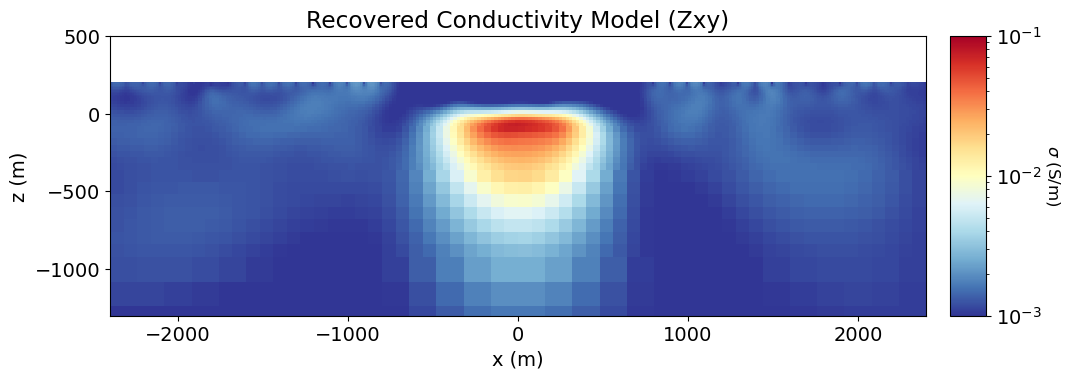

In [28]:
norm = LogNorm(vmin=1e-3, vmax=1e-1)

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * recovered_model_xy,
    ax=ax1,
    # grid=True,
    pcolor_opts={"norm": norm, "cmap": mpl.cm.RdYlBu_r},
)
ax1.set_xlim(locations[:, 0].min(), locations[:, 0].max())
ax1.set_ylim(np.max(topo_2d[:, -1]) - 1500, np.max(topo_2d[:, -1])+300)
ax1.set_title("Recovered Conductivity Model (Zxy)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)

plt.show()


In [29]:
dpred_xy = inv_prob_xy.dpred

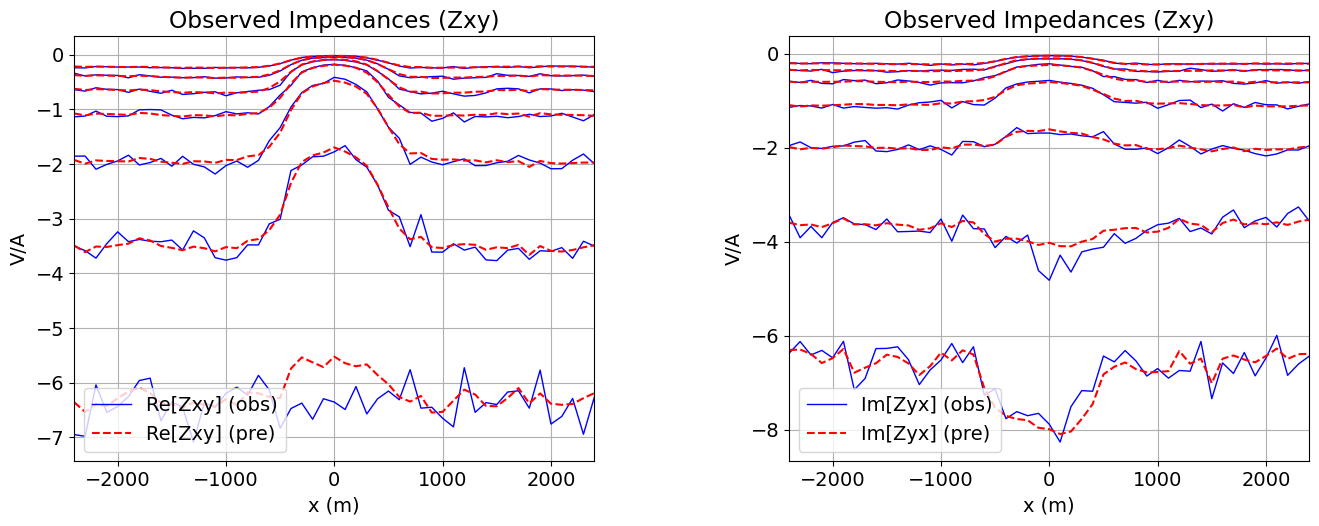

In [30]:
dpred_xy_plotting = np.reshape(dpred_xy, (len(frequencies), 2, len(locations)))
dobs_xy_plotting = np.reshape(dobs_Zxy, (len(frequencies), 2, len(locations)))
                               
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.85])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.85])

for kk in range(len(frequencies)):
    ax1.plot(locations[:, 0], dobs_xy_plotting[kk, 0, :], 'b', lw=1)
    ax1.plot(locations[:, 0], dpred_xy_plotting[kk, 0, :], 'r--', lw=1.5)
    ax2.plot(locations[:, 0], dobs_xy_plotting[kk, 1, :], 'b', lw=1)
    ax2.plot(locations[:, 0], dpred_xy_plotting[kk, 1, :], 'r--', lw=1.5)

ax1.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
ax1.set_xlabel("x (m)", labelpad=5)
ax1.grid(which='both')
ax1.set_ylabel("V/A", labelpad=5)
ax1.set_title("Observed Impedances (Zxy)")
ax1.legend(['Re[Zxy] (obs)', 'Re[Zxy] (pre)'], loc='lower left')

ax2.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
ax2.set_xlabel("x (m)", labelpad=5)
ax2.grid(which='both')
ax2.set_ylabel("V/A", labelpad=5)
ax2.set_title("Observed Impedances (Zxy)")
ax2.legend(['Im[Zyx] (obs)', 'Im[Zyx] (pre)'], loc='lower left')

plt.show(fig)

## Zyx Inversion

### Survey

In [31]:
source_list_yx = []

# First loop over frequencies
for freq in frequencies:
    
    receiver_list_yx = []

    # Next loop over receiver types
    for comp in ['real', 'imag']:
        # Locations of corresponding electric and magnetic
        # field measurements set separately
        receiver_list_yx.append(
            nsem.receivers.Impedance(
                locations_e=locations_shifted,
                locations_h=locations_shifted,
                orientation='yx',
                component=comp,
            )
        )

    source_list_yx.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_yx, frequency=freq,
        )
    )

survey_yx = nsem.survey.Survey(source_list_yx)

### Define the Forward Simulation

In [32]:
simulation_yx = nsem.simulation.Simulation2DMagneticFieldFictitious(
    mesh,
    survey=survey_yx,
    sigma_background=sigma_1d,
    sigmaMap=log_conductivity_map,
    solver=get_default_solver()
)

### Define the Data

In [33]:
data_yx = data.Data(survey=survey_yx, dobs=np.reshape(dobs_Zyx, -1), standard_deviation=np.reshape(unc_yx, -1))

### Define the Data Misfit

In [34]:
dmis_yx = data_misfit.L2DataMisfit(simulation=simulation_yx, data=data_yx)

### Define the Regularization

In [35]:
reg_yx = regularization.WeightedLeastSquares(
    mesh,
    active_cells=active_cells,
    alpha_s=1e-6*dh**-2,
    alpha_x=1,
    alpha_y=1,
)

### Define the Optimization Algorithm

In [36]:
opt_yx = optimization.InexactGaussNewton(
    maxIter=40, maxIterLS=20, cg_maxiter=300, cg_rtol=0.05
)

### Define the Inverse Problem

In [37]:
inv_prob_yx = inverse_problem.BaseInvProblem(dmis_yx, reg_yx, opt_yx, beta=100)

### Provide Inversion Directives

In [38]:
update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
beta_schedule = directives.BetaSchedule(coolingFactor=2.5, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.1)

directives_list_yx = [
    update_jacobi,
    beta_schedule,
    target_misfit,
]

### Define and Run the Inversion

In [39]:
# Here we combine the inverse problem and the set of directives
inv_yx = inversion.BaseInversion(inv_prob_yx, directives_list_yx)

# Run the inversion
recovered_model_yx = inv_yx.run(starting_model)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.



Running inversion with SimPEG v0.24.1.dev132+g2e9062041


INFO: Directive TargetMisfit: Target data misfit is 754.6


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.00e+02  7.44e+05  0.00e+00  7.44e+05                                 
   1  1.00e+02  5.78e+04  7.69e+01  6.55e+04    2.49e+04      0              
   2  1.00e+02  8.63e+03  1.22e+02  2.08e+04    3.26e+03      0              
   3  1.00e+02  4.79e+03  1.15e+02  1.63e+04    6.23e+02      0              
   4  4.00e+01  2.21e+03  1.52e+02  8.31e+03    2.59e+02      0              
   5  4.00e+01  2.32e+03  1.49e+02  8.26e+03    5.07e+01      0              
   6  4.00e+01  2.25e+03  1.50e+02  8.25e+03    1.22e+01      0              
   7  1.60e+01  1.32e+03  1.86e+02  4.30e+03    1.14e+02      0              
   8  1.60e+01  1.33e+03  1.85e+02  4.28e+03    2.50e+01      0              
   9  1.60e+01  1.30e+03  1.86e+02  4.28e+03    6.29e+00      0

In [40]:
dpred_yx = inv_prob_yx.dpred

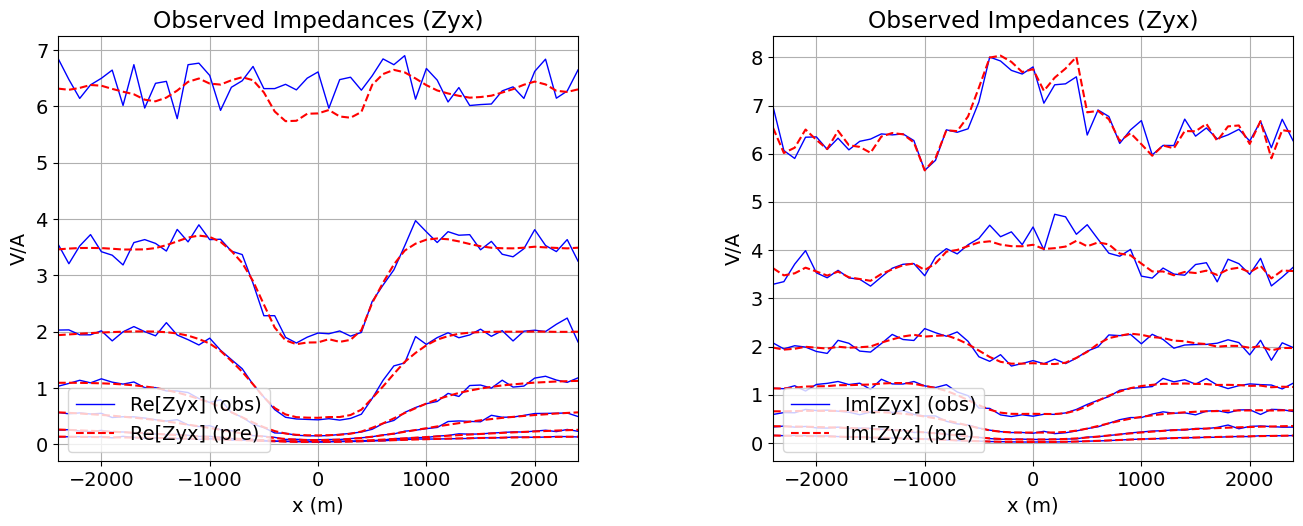

In [41]:
dpred_yx_plotting = np.reshape(dpred_yx, (len(frequencies), 2, len(locations)))
dobs_yx_plotting = np.reshape(dobs_Zyx, (len(frequencies), 2, len(locations)))
                               
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_axes([0.05, 0.1, 0.4, 0.85])
ax2 = fig.add_axes([0.6, 0.1, 0.4, 0.85])

for kk in range(len(frequencies)):
    ax1.plot(locations[:, 0], dobs_yx_plotting[kk, 0, :], 'b', lw=1)
    ax1.plot(locations[:, 0], dpred_yx_plotting[kk, 0, :], 'r--', lw=1.5)
    ax2.plot(locations[:, 0], dobs_yx_plotting[kk, 1, :], 'b', lw=1)
    ax2.plot(locations[:, 0], dpred_yx_plotting[kk, 1, :], 'r--', lw=1.5)

ax1.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
ax1.set_xlabel("x (m)", labelpad=5)
ax1.grid(which='both')
ax1.set_ylabel("V/A", labelpad=5)
ax1.set_title("Observed Impedances (Zyx)")
ax1.legend(['Re[Zyx] (obs)', 'Re[Zyx] (pre)'], loc='lower left')

ax2.set_xlim([locations[:, 0].min(), locations[:, 0].max()])
ax2.set_xlabel("x (m)", labelpad=5)
ax2.grid(which='both')
ax2.set_ylabel("V/A", labelpad=5)
ax2.set_title("Observed Impedances (Zyx)")
ax2.legend(['Im[Zyx] (obs)', 'Im[Zyx] (pre)'], loc='lower left')

plt.show(fig)

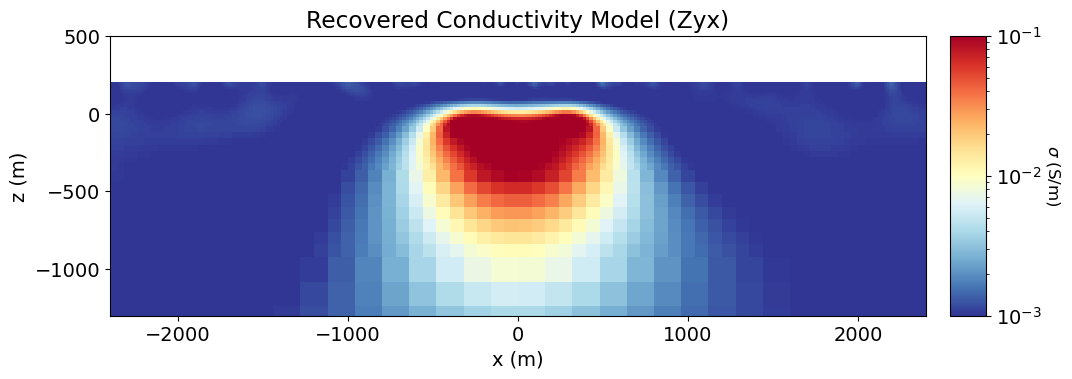

In [42]:
norm = LogNorm(vmin=1e-3, vmax=1e-1)

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
mesh.plot_image(
    plotting_map * recovered_model_yx,
    ax=ax1,
    # grid=True,
    pcolor_opts={"norm": norm, "cmap": mpl.cm.RdYlBu_r},
)
ax1.set_xlim(locations[:, 0].min(), locations[:, 0].max())
ax1.set_ylim(np.max(topo_2d[:, -1]) - 1500, np.max(topo_2d[:, -1])+300)
ax1.set_title("Recovered Conductivity Model (Zyx)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.RdYlBu_r
)
cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)

plt.show()
